---
title: "Diagnostics of subspaces obtained from split replication CV"
author: "Saikat Banerjee"
format:
  html: default
date: "2026-06-02"
file-modified: "2026-06-02"
abstract: "This notebook documents the diagnostics of subspaces obtained from PGC data using NNM-Corr model and PGD-AFW solver."
---

## Background

We expected the projection distance between subspaces to be monotonically decreasing. 
For the NNM-Corr model, we found that the projection distances between subspaces are very noisy.
[Click here to view the analysis notebook](./2026-04-30-cvsr-results.ipynb).

Here, we try to diagnose the source of this noise.


In [1]:
import re
import json
import pickle
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from pymir import mpl_stylesheet
from pymir import mpl_utils
mpl_stylesheet.banskt_presentation(splinecolor = 'black', dpi = 300)

from matplotlib import colormaps as mpl_cmaps
import matplotlib.colors as mpl_colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
data_root = "/gpfs/commons/groups/knowles_lab/data/PsychGen/analysis/clorinn/cv_split_replication"
prefix = "pgd_afw_nnm_corr"
stability_out_dir = Path(data_root) / "stability"
subspace_out_dir = Path(data_root) / "subspace"
fit_result_out_dir = Path(data_root) / "fit_result"

In [5]:
def load_stability_jsons(stability_dir, prefix):
    stability_dir = Path(stability_dir)
    paths = sorted(stability_dir.glob(f"{prefix}_r*.json"))

    records = []
    for path in paths:
        with open(path) as fh:
            rec = json.load(fh)
        rec["_path"] = str(path)
        records.append(rec)

    return records


def build_by_k_metrics_grid(records, metric, *, duplicate="error"):
    rows = []

    for rec in records:
        nucnorm = int(round(float(rec["nucnorm"])))

        for entry in rec["by_k"]:
            value = entry[metric]
            rows.append({
                "nucnorm": nucnorm, 
                "k": int(entry["k"]), 
                metric: float(value),
            })

    long_df = pd.DataFrame(rows)

    dup_mask = long_df.duplicated(subset=["nucnorm", "k"], keep=False)
    # Look for duplicates. This can happen if coarse and fine grids
    # contain the same nucnorm.
    if dup_mask.any():
        keep = "first" if duplicate == "first" else "last"
        long_df = (
            long_df
            .sort_values(["nucnorm", "k"])
            .drop_duplicates(subset=["nucnorm", "k"], keep=keep)
        )
    grid_df = (
        long_df
        .pivot(index="k", columns="nucnorm", values=metric)
        .sort_index(axis=0)
        .sort_index(axis=1)
    )

    grid_df.index.name = "k"
    grid_df.columns.name = "nucnorm"

    return grid_df

## The Problem

The solution path is not smooth. There are spikes along the projected distance matrix. We reproduce the heatmap here for posterity.

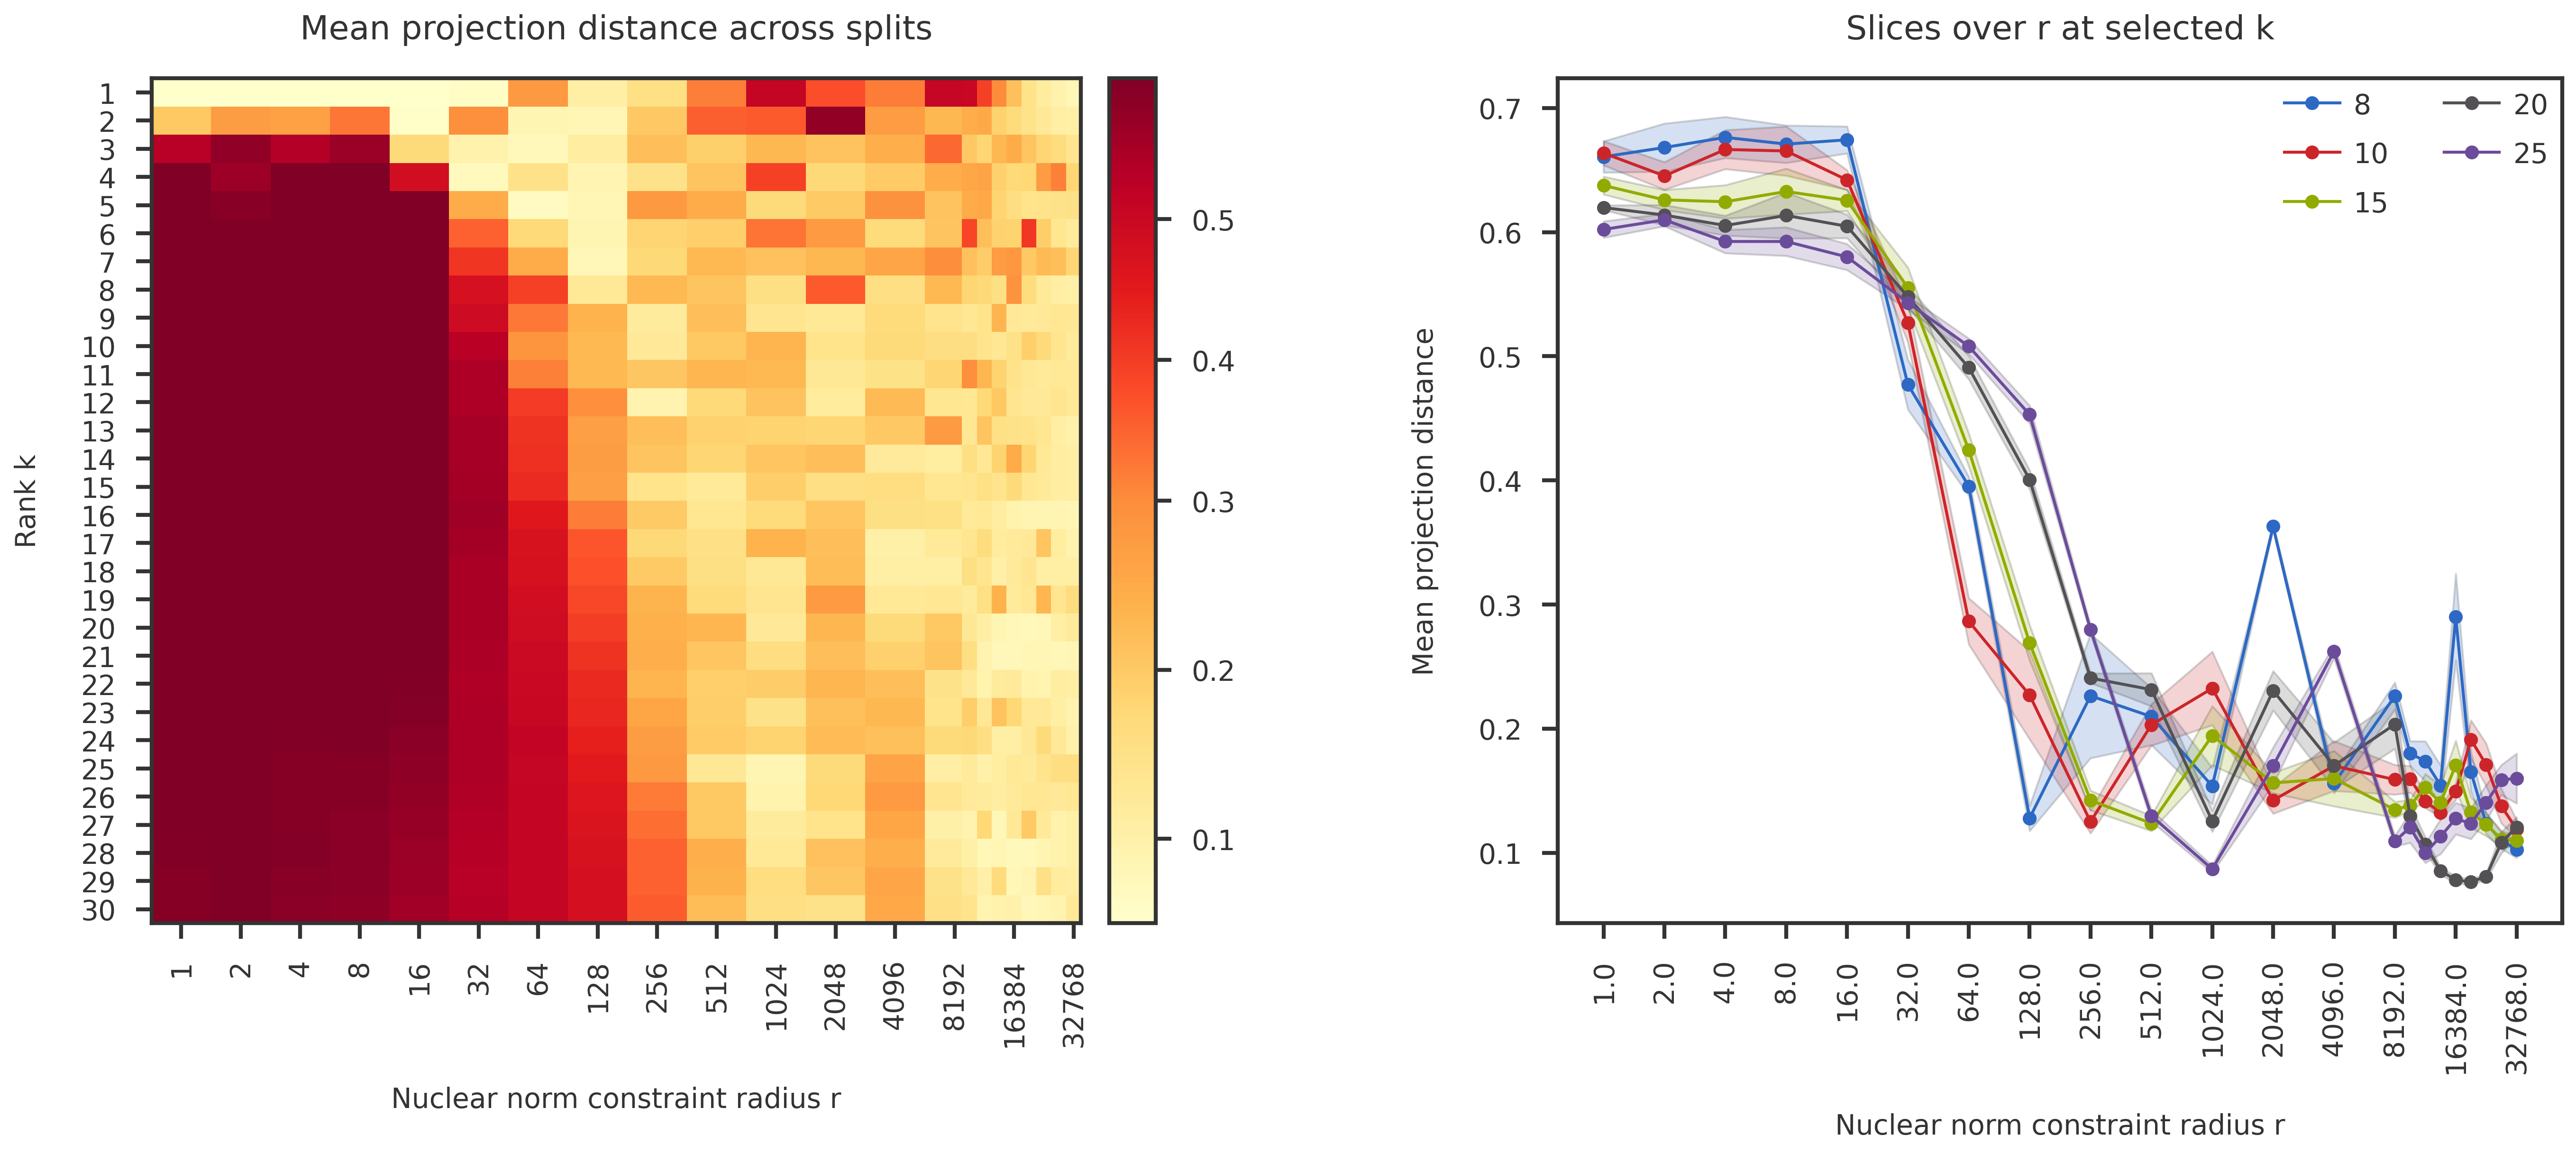

In [6]:
def centers_to_edges(x):
    x = np.asarray(x, dtype=float)
    edges = np.empty(len(x) + 1)
    edges[1:-1] = 0.5 * (x[:-1] + x[1:])
    edges[0] = x[0] - 0.5 * (x[1] - x[0])
    edges[-1] = x[-1] + 0.5 * (x[-1] - x[-2])
    return edges

def plot_heatmap(ax, X, rank_list, k_list,
        vmin=0, vcenter=0.9, vmax=1.0,
        scale="log2"):

    cmap1 = mpl_cmaps.get_cmap("YlOrRd").copy()
    cmap1.set_bad("w")
    norm1 = mpl_colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    r, rticks, rlabels = get_r_scaled(rank_list, scale=scale)

    x_edges = centers_to_edges(r)
    y_edges = np.arange(len(k_list) + 1) - 0.5

    im1 = ax.pcolormesh(x_edges, y_edges, X, cmap=cmap1, norm=norm1, shading="auto")

    # match imshow(origin="upper")
    ax.set_ylim(len(k_list) - 0.5, -0.5)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.2)
    cbar = plt.colorbar(im1, cax=cax, fraction=0.1)

    ax.set_xlabel("Nuclear norm constraint radius r")
    ax.set_ylabel("Rank k")

    ax.set_yticks(np.arange(len(k_list)))
    ax.set_yticklabels([str(int(k)) for k in k_list])

    ax.set_xticks(rticks)
    ax.set_xticklabels([str(int(r)) for r in rlabels], rotation=90)

    return im1

def plot_heatmap_(ax, X, rank_list, k_list,
        vmin = 0, vcenter = 0.9, vmax = 1.0):
    cmap1 = mpl_cmaps.get_cmap("YlOrRd").copy()
    cmap1.set_bad("w")
    norm1 = mpl_colors.TwoSlopeNorm(vmin = vmin, vcenter = vcenter, vmax = vmax)
    im1 = ax.imshow(X, cmap = cmap1, norm = norm1, origin = 'upper', aspect='auto')
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.2)
    cbar = plt.colorbar(im1, cax=cax, fraction = 0.1)

    ax.set_xlabel("Nuclear norm constraint radius r")
    ax.set_ylabel("Rank k")
    ax.set_yticks(np.arange(len(k_list)))
    ax.set_yticklabels([str(int(k)) for k in k_list])
    ax.set_xticks(np.arange(len(rank_list)))
    ax.set_xticklabels([str(int(r)) for r in rank_list], rotation=90)    
    return

def get_r_scaled(x, scale="log2"):
    x = np.asarray(x, dtype=float)
    powers = np.arange(np.ceil(np.log2(x.min())), np.floor(np.log2(x.max())) + 1)
    xlabels = 2 ** powers
    
    if scale == "log10":
        xscale = np.log10(x)
        xticks = np.log10(xlabels)
    elif scale == "log2":
        xscale = np.log2(x)
        xticks = np.log2(xlabels)
    else:
        xscale = x
        xticks = xlabels

    return xscale, xticks, xlabels

def make_projection_distance_figure(prefix,
        vmin=0.09, vcenter=0.12, vmax=0.2):
    records = load_stability_jsons(stability_out_dir, prefix)
    dist_df = build_by_k_metrics_grid(records, "mean_dist", duplicate="first")
    se_dist_df = build_by_k_metrics_grid(records, "se_dist", duplicate="first")
    rank_list = dist_df.columns.to_numpy()
    k_list = dist_df.index.to_numpy()
 
    fig = plt.figure(figsize=(18, 8), constrained_layout=True)
    gs = fig.add_gridspec(nrows=1, ncols=2, 
                          width_ratios=[1, 1],  # heatmap, line plot
                          wspace=0.2, hspace=0.05,
                         )
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])

    im1 = plot_heatmap(ax1, dist_df.to_numpy(), rank_list, k_list, 
                 vmin=vmin, vcenter=vcenter, vmax=vmax)
    ax1.set_title("Mean projection distance across splits", pad = 20)

    # Plot rows of the heatmap as a line plot. 
    # Makes it easier to see the plateau onset for chosen ranks.
    k_choose = [8, 10, 15, 20, 25]
    r, rticks, rlabels = get_r_scaled(rank_list, scale='log2')
    for k in k_choose:
        y = dist_df.loc[k].to_numpy()
        se = se_dist_df.loc[k].to_numpy()
        ax2.plot(r, y, 'o-', label=f"{k:d}")
        ax2.fill_between(r, y - se, y + se, alpha=0.2)
    ax2.set_xlabel("Nuclear norm constraint radius r")
    ax2.set_ylabel(f"Mean projection distance")
    ax2.set_xticks(rticks)
    ax2.set_xticklabels(rlabels, rotation=90)
    ax2.set_title(f"Slices over r at selected k", pad = 20)
    ax2.legend(loc = 'upper right', frameon = False, handlelength = 2, ncol = 2)
    
    plt.show()
    

vmin, vcenter, vmax = 0.05, 0.3, 0.6
make_projection_distance_figure(prefix, vmin=vmin, vcenter=vcenter, vmax=vmax)

At `k=20`, the projection distance decreases up to `r=1024` and then spikes at `r=2048`, oscillates at `r=4096` and `r=8192` before tapering off.

At `k=10` and `k=15`, the projection distance spikes at `r=1024` before tapering off. 

At `k=25`, the projection distance spikes at `r=4096` before tapering off.

Let's look at some suspicious cells:
```
(k=6,  r=19484)**
(k=8,  r=2048)**
(k=10, r=512)
(k=10, r=1024)
(k=15, r=1024)
(k=20, r=2048)
(k=20, r=8192)
(k=25, r=4096)
```

In [7]:
suspicious_cells=[
    (6, 19484),
    (8, 2048),
    (10, 512),
    (10, 1024),
    (15, 1024),
    (20, 2048),
    (20, 8192),
    (25, 4096),
]

## Look at per-repeat distances, not only the mean

In [9]:
def build_metrics_per_pair(records, metric):
    rows = []

    for rec in records:
        nucnorm = int(round(float(rec["nucnorm"])))

        pair_labels = rec["pair_labels"]
        for entry in rec["by_k"]:
            pair_values = entry[metric]
            k = int(entry["k"])
            for label, value in zip(pair_labels, pair_values):
                rows.append({
                    "nucnorm": nucnorm, 
                    "k": k, 
                    "pair_label": label,
                    metric: float(value),
                })

    long_df = pd.DataFrame(rows)
    return long_df

def print_metrics_per_pair(long_df, cells, metric):
    for (k, r) in cells:
        query_str = f"k == {k} and nucnorm == {r}"
        values = long_df.query(query_str)[metric].to_list()
        values_str = ", ".join([f"{d:.3f}" for d in values])
        print(f"(k={k}, r={r}) \t {values_str}")

records = load_stability_jsons(stability_out_dir, prefix)
dist_df = build_by_k_metrics_grid(records, "mean_dist", duplicate="first")
dist_long_df = build_metrics_per_pair(records, "distances")
print_metrics_per_pair(dist_long_df, suspicious_cells, "distances")

(k=6, r=19484) 	 0.415, 0.422, 0.427, 0.392, 0.386
(k=8, r=2048) 	 0.362, 0.359, 0.369, 0.365, 0.360
(k=10, r=512) 	 0.203, 0.243, 0.232, 0.149, 0.188
(k=10, r=1024) 	 0.146, 0.318, 0.274, 0.225, 0.199
(k=15, r=1024) 	 0.220, 0.267, 0.198, 0.154, 0.133
(k=20, r=2048) 	 0.249, 0.283, 0.220, 0.199, 0.203
(k=20, r=8192) 	 0.170, 0.223, 0.240, 0.240, 0.144
(k=25, r=4096) 	 0.247, 0.262, 0.257, 0.265, 0.279


## Check objective monotonicity per split

In [10]:
def build_convergence_per_split(rank_list, n_repeat=5, n_split=2):
    ranks = np.asarray(rank_list)
    rows = []
    for r in np.unique(ranks):
        for s in range(n_repeat):
            fit_result_out_path = fit_result_out_dir / f"{prefix}_r{r}_s{s}.pkl"
            with open(fit_result_out_path, 'rb') as f:
                fit_result = pickle.load(f)
            for i in range(n_split):
                loss = np.array(fit_result[i]['final_result'].history.loss)
                relative_loss = (loss[-2] - loss[-1]) / loss[-2]
                rows.append({
                    "nucnorm": r,
                    "repeat": s,
                    "split": i,
                    "loss": fit_result[i]['final_result'].loss,
                    "rel_loss": relative_loss,
                    "duality_gap": fit_result[i]['final_result'].duality_gap,
                    "nuclear_norm": fit_result[i]['final_result'].metrics['nuclear_norm'],
                })
    df = pd.DataFrame(rows)
    return df
            
rank_list = dist_df.columns.to_list()
convergence_df = build_convergence_per_split(rank_list)

In [11]:
convergence_df.query("repeat==0 and split==0")

,nucnorm,repeat,split,loss,rel_loss,duality_gap,nuclear_norm
0,1,0,0,2.617907e+06,9.510999e-13,2.528538e-06,0.707107
10,2,0,0,2.616726e+06,1.090869e-13,2.739350e-07,1.414214
20,4,0,0,2.614456e+06,1.342524e-11,3.757306e-05,2.828427
30,8,0,0,2.610283e+06,1.218090e-10,4.249882e-04,5.656854
40,16,0,0,2.603314e+06,2.312553e-11,2.910869e-01,11.313708
50,32,0,0,2.591879e+06,8.634181e-12,6.933025e-01,22.627417
60,64,0,0,2.572111e+06,4.154924e-12,8.730343e-01,45.254834
70,128,0,0,2.538881e+06,1.163566e-12,9.898658e-01,90.509668
80,256,0,0,2.486307e+06,6.658172e-13,1.468620e+00,181.019334
90,512,0,0,2.399024e+06,3.935152e-10,5.830802e+01,362.038216


Objective monotonicity is good. But the high-r fits do not look fully solved because the fitted nuclear norm falls far below the available radius while the duality gap becomes large.

## Are the spikes caused by small spectral gaps?

In [14]:
def _pair_to_mat_indices(pair_labels, mat_labels):
    """
    Map each pair label 'A-B' to (mat_idx_A, mat_idx_B).
    """
    mat_to_idx = {label: i for i, label in enumerate(mat_labels)}
    return [tuple(mat_to_idx[s] for s in pl.split("-")) for pl in pair_labels]

def _pair_label_to_repeat_fold_ids(pair_label):
    # 'rep0_f0-rep0_f1', 'rep1_f0-rep1_f1', ...
    pattern = r"rep(\d+)_f(\d+)-rep(\d+)_f(\d+)"
    m = re.match(pattern, pair_label)
    repeat_id = int(m.group(1))
    if repeat_id != int(m.group(3)):
        raise ValueError(f"Repeat IDs dont match: {m.group(1)} and {m.group(3)}")
    fold_id_1 = int(m.group(2))
    fold_id_2 = int(m.group(4))
    return repeat_id, fold_id_1, fold_id_2

def spectral_gap_from_record(record):
    rows = []

    nucnorm     = int(round(float(record["nucnorm"])))
    mat_labels  = record["mat_labels"]
    pair_labels = record["pair_labels"]
    n_matrices  = record["n_matrices"]
    n_pairs     = record["n_pairs"]
    
    by_k = sorted(record["by_k"], key=lambda x: int(x["k"]))
    cum_energy = np.array([e["energies"]  for e in by_k], dtype=np.float64)  # (n_factors, n_mats)
    dist_kp    = np.array([e["distances"] for e in by_k], dtype=np.float64)  # (n_factors, n_pairs)  
    k_values   = [int(e["k"]) for e in by_k]

    E0 = np.zeros((1, n_matrices), dtype=float)
    E = np.vstack([E0, cum_energy])
    
    delta_E = np.diff(E, axis=0) # rows corresponding to k_values
    delta_E = np.clip(delta_E, 0.0, None) # Numerical cleanup
    
    # normalized singular values: s_k / ||s||_2
    s_norm = np.sqrt(delta_E)
    
    pair_mats  = _pair_to_mat_indices(pair_labels, mat_labels)
    for p, (ia, ib) in enumerate(pair_mats):
        for idx, k in enumerate(k_values):
            row = {
                "nucnorm": nucnorm,
                "k": k,
                "pair_label": pair_labels[p],
                "pair_idx": p,
                "distance": dist_kp[idx, p],
                "energy": np.nanmin([cum_energy[idx, ia], cum_energy[idx, ib]]),
                "s_norm": np.nanmin([s_norm[idx, ia], s_norm[idx, ib]]),
            }
            # Gap at k requires k+1, so cannot compute for the last stored k.
            if idx + 1 < len(k_values):
                s_ka, s_kb = s_norm[idx, ia], s_norm[idx, ib]
                s_next_a, s_next_b = s_norm[idx + 1, ia], s_norm[idx + 1, ib]
                
                gap_a = s_ka - s_next_a
                gap_b = s_kb - s_next_b
                
                rel_gap_a = gap_a / s_ka if s_ka > 0 else np.nan
                rel_gap_b = gap_b / s_kb if s_kb > 0 else np.nan
                
                gap_ratio_a = s_next_a / s_ka if s_ka > 0 else np.nan
                gap_ratio_b = s_next_b / s_kb if s_kb > 0 else np.nan

                row.update({
                    "s_gap": np.nanmin([gap_a, gap_b]),
                    "rel_s_gap": np.nanmin([rel_gap_a, rel_gap_b]),
                    "gap_ratio": np.nanmax([gap_ratio_a, gap_ratio_b]),
                })
            else:
                row.update({
                    "s_gap": np.nan,
                    "rel_s_gap": np.nan,
                    "gap_ratio": np.nan,
                })

            rows.append(row)
    return rows

def load_subspace_npz(subspace_dir, prefix):
    subspace_dir = Path(subspace_dir)
    rows = []
    for path in subspace_dir.glob(f"{prefix}_r*.npz"):
        with np.load(path, allow_pickle=False) as data:
            n_folds = int(data["n_folds"])
            nucnorm = data["nucnorm"].item()
            repeat_id = data["repeat_id"].item()
            for f in range(n_folds):
                s = data[f"s_f{f}"]
                n_factors = len(s)
                row = {
                    "nucnorm": nucnorm,
                    "repeat_id": repeat_id,
                    "fold_id": f,
                }
                row.update({f"s{k}": s[k] for k in range(n_factors)})
                rows.append(row)
    df = (pd.DataFrame(rows)
              .sort_values(["nucnorm","repeat_id", "fold_id"])
              .reset_index(drop=True))
    return df


def spectral_gap_from_subspace(subspace_df, record):
    
    def get_subspace_spectrum(subspace_df, repeat_id, fold_id):
        df = subspace_df[
                (subspace_df["repeat_id"] == repeat_id) &
                (subspace_df["fold_id"] == fold_id)
            ].reset_index(drop=True)
        return df.sort_values(["nucnorm"]).reset_index(drop=True)
    
    def get_eigvalue(df, r, k_idx):
        return float(df[df["nucnorm"] == r][f"s{k_idx}"].iloc[0])
    
    rows = []

    nucnorm     = int(round(float(record["nucnorm"])))
    mat_labels  = record["mat_labels"]
    pair_labels = record["pair_labels"]
    n_matrices  = record["n_matrices"]
    n_pairs     = record["n_pairs"]
    
    by_k = sorted(record["by_k"], key=lambda x: int(x["k"]))
    dist_kp    = np.array([e["distances"] for e in by_k], dtype=np.float64)  # (n_factors, n_pairs)  
    k_values   = [int(e["k"]) for e in by_k]
    
    for p, pair_label in enumerate(pair_labels):
        repeat_id, fold_id_1, fold_id_2 = _pair_label_to_repeat_fold_ids(pair_label)
        df_fold_1 = get_subspace_spectrum(subspace_df, repeat_id, fold_id_1)
        df_fold_2 = get_subspace_spectrum(subspace_df, repeat_id, fold_id_2)
        s_0a = get_eigvalue(df_fold_1, nucnorm, 0)
        s_0b = get_eigvalue(df_fold_2, nucnorm, 0)
        for idx, k in enumerate(k_values):
            s_ka = get_eigvalue(df_fold_1, nucnorm, idx)
            s_kb = get_eigvalue(df_fold_2, nucnorm, idx)
            row = {
                "nucnorm": nucnorm,
                "k": k,
                "pair_label": pair_label,
                "pair_idx": p,
                "distance": dist_kp[idx, p],
                "eigvalue": np.min([s_ka, s_kb]),
                "s_norm": np.nanmin([s_ka/s_0a, s_kb/s_0b])
            }
            
            # Gap at k requires k+1, so cannot compute for the last stored k.
            if idx + 1 < len(k_values):
                s_next_a = get_eigvalue(df_fold_1, nucnorm, idx+1)
                s_next_b = get_eigvalue(df_fold_2, nucnorm, idx+1)
                
                gap_a = s_ka - s_next_a
                gap_b = s_kb - s_next_b
                
                rel_gap_a = gap_a / s_ka if s_ka > 0 else np.nan
                rel_gap_b = gap_b / s_kb if s_kb > 0 else np.nan
                
                gap_ratio_a = s_next_a / s_ka if s_ka > 0 else np.nan
                gap_ratio_b = s_next_b / s_kb if s_kb > 0 else np.nan

                row.update({
                    "s_gap": np.nanmin([gap_a, gap_b]),
                    "rel_s_gap": np.nanmin([rel_gap_a, rel_gap_b]),
                    "gap_ratio": np.nanmax([gap_ratio_a, gap_ratio_b]),
                })
            else:
                row.update({
                    "s_gap": np.nan,
                    "rel_s_gap": np.nan,
                    "gap_ratio": np.nan,
                })

            rows.append(row)
    return rows
    
def build_spectral_gap_pair(records, subspace = None):
    rows = []
    for record in records:
        if subspace is None:
            rows.extend(spectral_gap_from_record(record))
        else:
            rows.extend(spectral_gap_from_subspace(subspace, record))

    return (
        pd.DataFrame(rows)
        .sort_values(["k", "nucnorm", "pair_idx"])
        .reset_index(drop=True)
    )

subspace_df = load_subspace_npz(subspace_out_dir, prefix)
energy_df = build_spectral_gap_pair(records, subspace = subspace_df)

In [15]:
energy_df

,nucnorm,k,pair_label,pair_idx,distance,eigvalue,s_norm,s_gap,rel_s_gap,gap_ratio
0,1,1,rep0_f0-rep0_f1,0,0.025156,0.707107,1.000000,0.707107,1.0,4.015523e-16
1,1,1,rep1_f0-rep1_f1,1,0.016287,0.707107,1.000000,0.707107,1.0,3.647497e-16
2,1,1,rep2_f0-rep2_f1,2,0.020491,0.707107,1.000000,0.707107,1.0,6.371862e-16
3,1,1,rep3_f0-rep3_f1,3,0.024985,0.707107,1.000000,0.707107,1.0,5.312698e-16
4,1,1,rep4_f0-rep4_f1,4,0.021932,0.707107,1.000000,0.707107,1.0,6.021974e-16
...,...,...,...,...,...,...,...,...,...,...
3295,32768,30,rep0_f0-rep0_f1,0,0.114999,155.626146,0.226711,NaN,NaN,NaN
3296,32768,30,rep1_f0-rep1_f1,1,0.121499,156.804912,0.231988,NaN,NaN,NaN
3297,32768,30,rep2_f0-rep2_f1,2,0.150105,158.057960,0.230397,NaN,NaN,NaN
3298,32768,30,rep3_f0-rep3_f1,3,0.112334,156.312662,0.230464,NaN,NaN,NaN


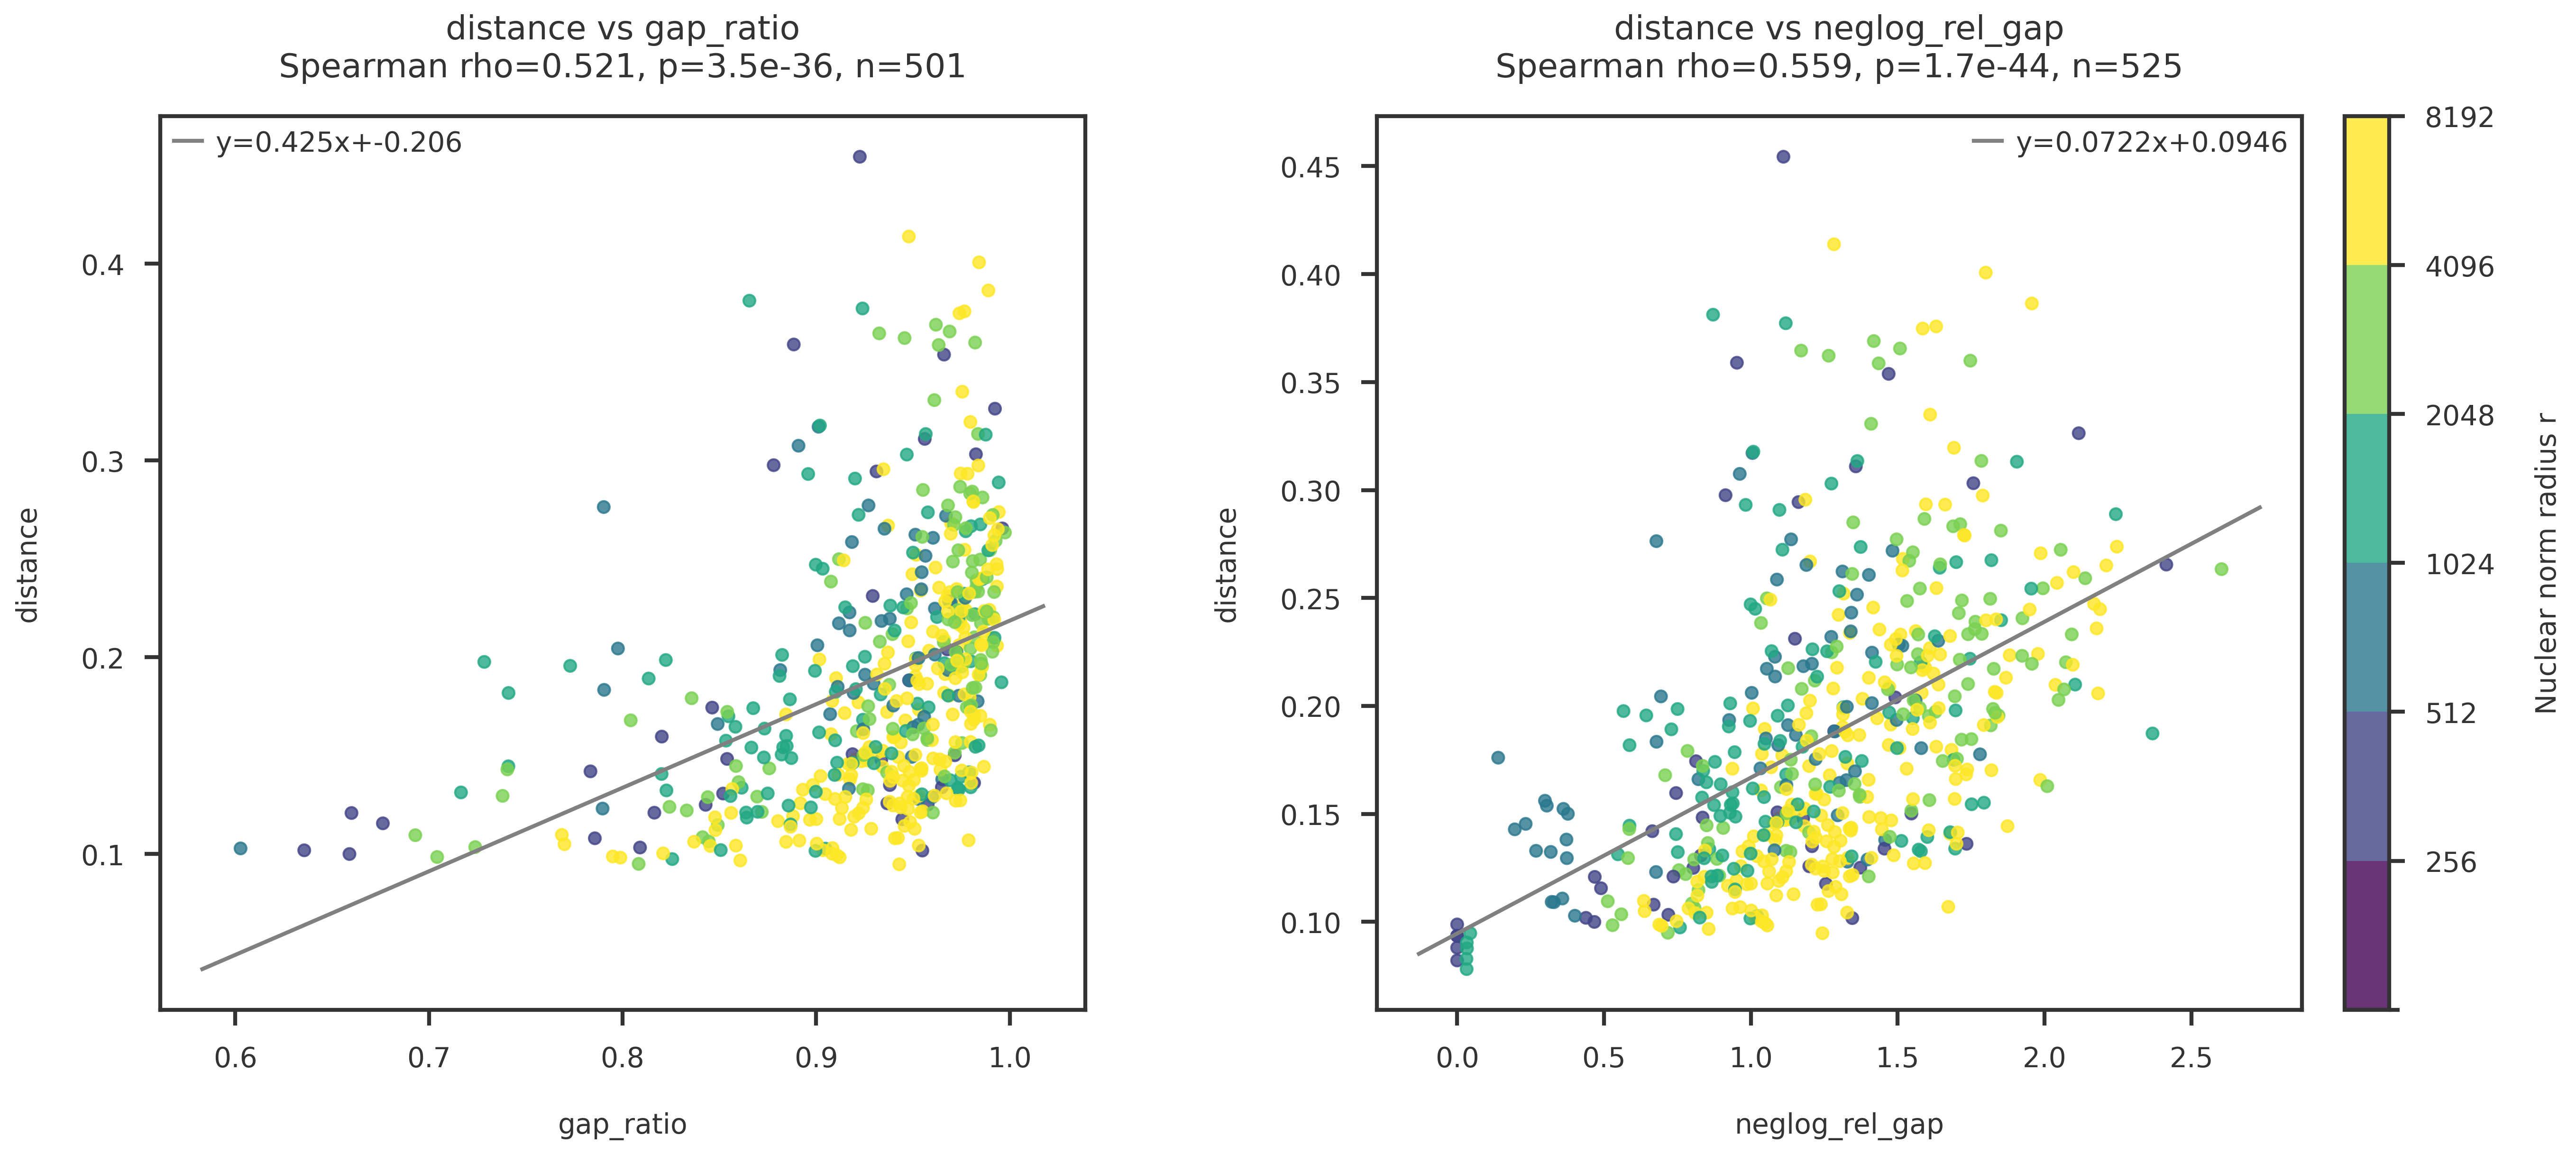

In [16]:
from scipy.stats import spearmanr

def make_gap_distance_scatter(ax, energy_df,
        x="gap_ratio", y="distance", add_fit=True,
        k_values=None, nucnorm_values=None, 
        min_s_norm=0.01, max_distance=0.5, min_gap_ratio=0.6, 
        color_by="nucnorm", cmap="viridis", color_norm=None):
    
    df = energy_df.copy()

    df = df[df["s_norm"] > min_s_norm]
    df = df[df["distance"] < max_distance]
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[x, y, color_by])
    
    if x == "gap_ratio":
        df = df[df["gap_ratio"] > min_gap_ratio]

    if k_values is not None:
        df = df[df["k"].isin(k_values)]

    if nucnorm_values is not None:
        df = df[df["nucnorm"].isin(nucnorm_values)]

    rho, pval = spearmanr(df[x], df[y])

    sc = ax.scatter(df[x], df[y], 
        c=df[color_by],
        cmap=cmap,
        norm=color_norm, alpha=0.8)
        

    if add_fit:
        xv = df[x].to_numpy(dtype=float)
        yv = df[y].to_numpy(dtype=float)

        m, b = np.polyfit(xv, yv, deg=1)

        # Use visible x-range for the fit line
        xlo, xhi = ax.get_xlim()
        xfit = np.linspace(xlo, xhi, 200)
        yfit = m * xfit + b

        ax.plot(xfit, yfit, lw=2, color='gray',label=f"y={m:.3g}x+{b:.3g}")
        ax.legend(frameon=False)

    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{y} vs {x}\nSpearman rho={rho:.3f}, p={pval:.2g}, n={len(df)}", pad=20)

    return df, sc

fig = plt.figure(figsize=(18, 8), constrained_layout=True)
gs = fig.add_gridspec(nrows=1, ncols=2, 
                      width_ratios=[1, 1],  # heatmap, line plot
                      wspace=0.1, hspace=0.05,
                     )
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
nucnorm_values = rank_list[8:14]
k_values = np.arange(5, 26)
energy_df["neglog_rel_gap"]   = -np.log10(energy_df["rel_s_gap"].clip(lower=1e-12))

# color_norm = mpl_colors.LogNorm(vmin=np.min(nucnorm_values), vmax=np.max(nucnorm_values))
color_norm = mpl_colors.BoundaryNorm(boundaries=[0] + nucnorm_values, ncolors=256)

df_gap_ratio, sc = make_gap_distance_scatter(ax1, energy_df, x="gap_ratio", 
                          nucnorm_values=nucnorm_values, k_values=k_values, color_norm=color_norm)
df_rel_gap, _    = make_gap_distance_scatter(ax2, energy_df, x="neglog_rel_gap", 
                          nucnorm_values=nucnorm_values, k_values=k_values, color_norm=color_norm)

cbar = fig.colorbar(sc, ax=[ax1, ax2], pad=0.02)
cbar.set_label("Nuclear norm radius r")
cbar.set_ticks(nucnorm_values)
cbar.set_ticklabels([str(int(r)) for r in nucnorm_values])

plt.show()

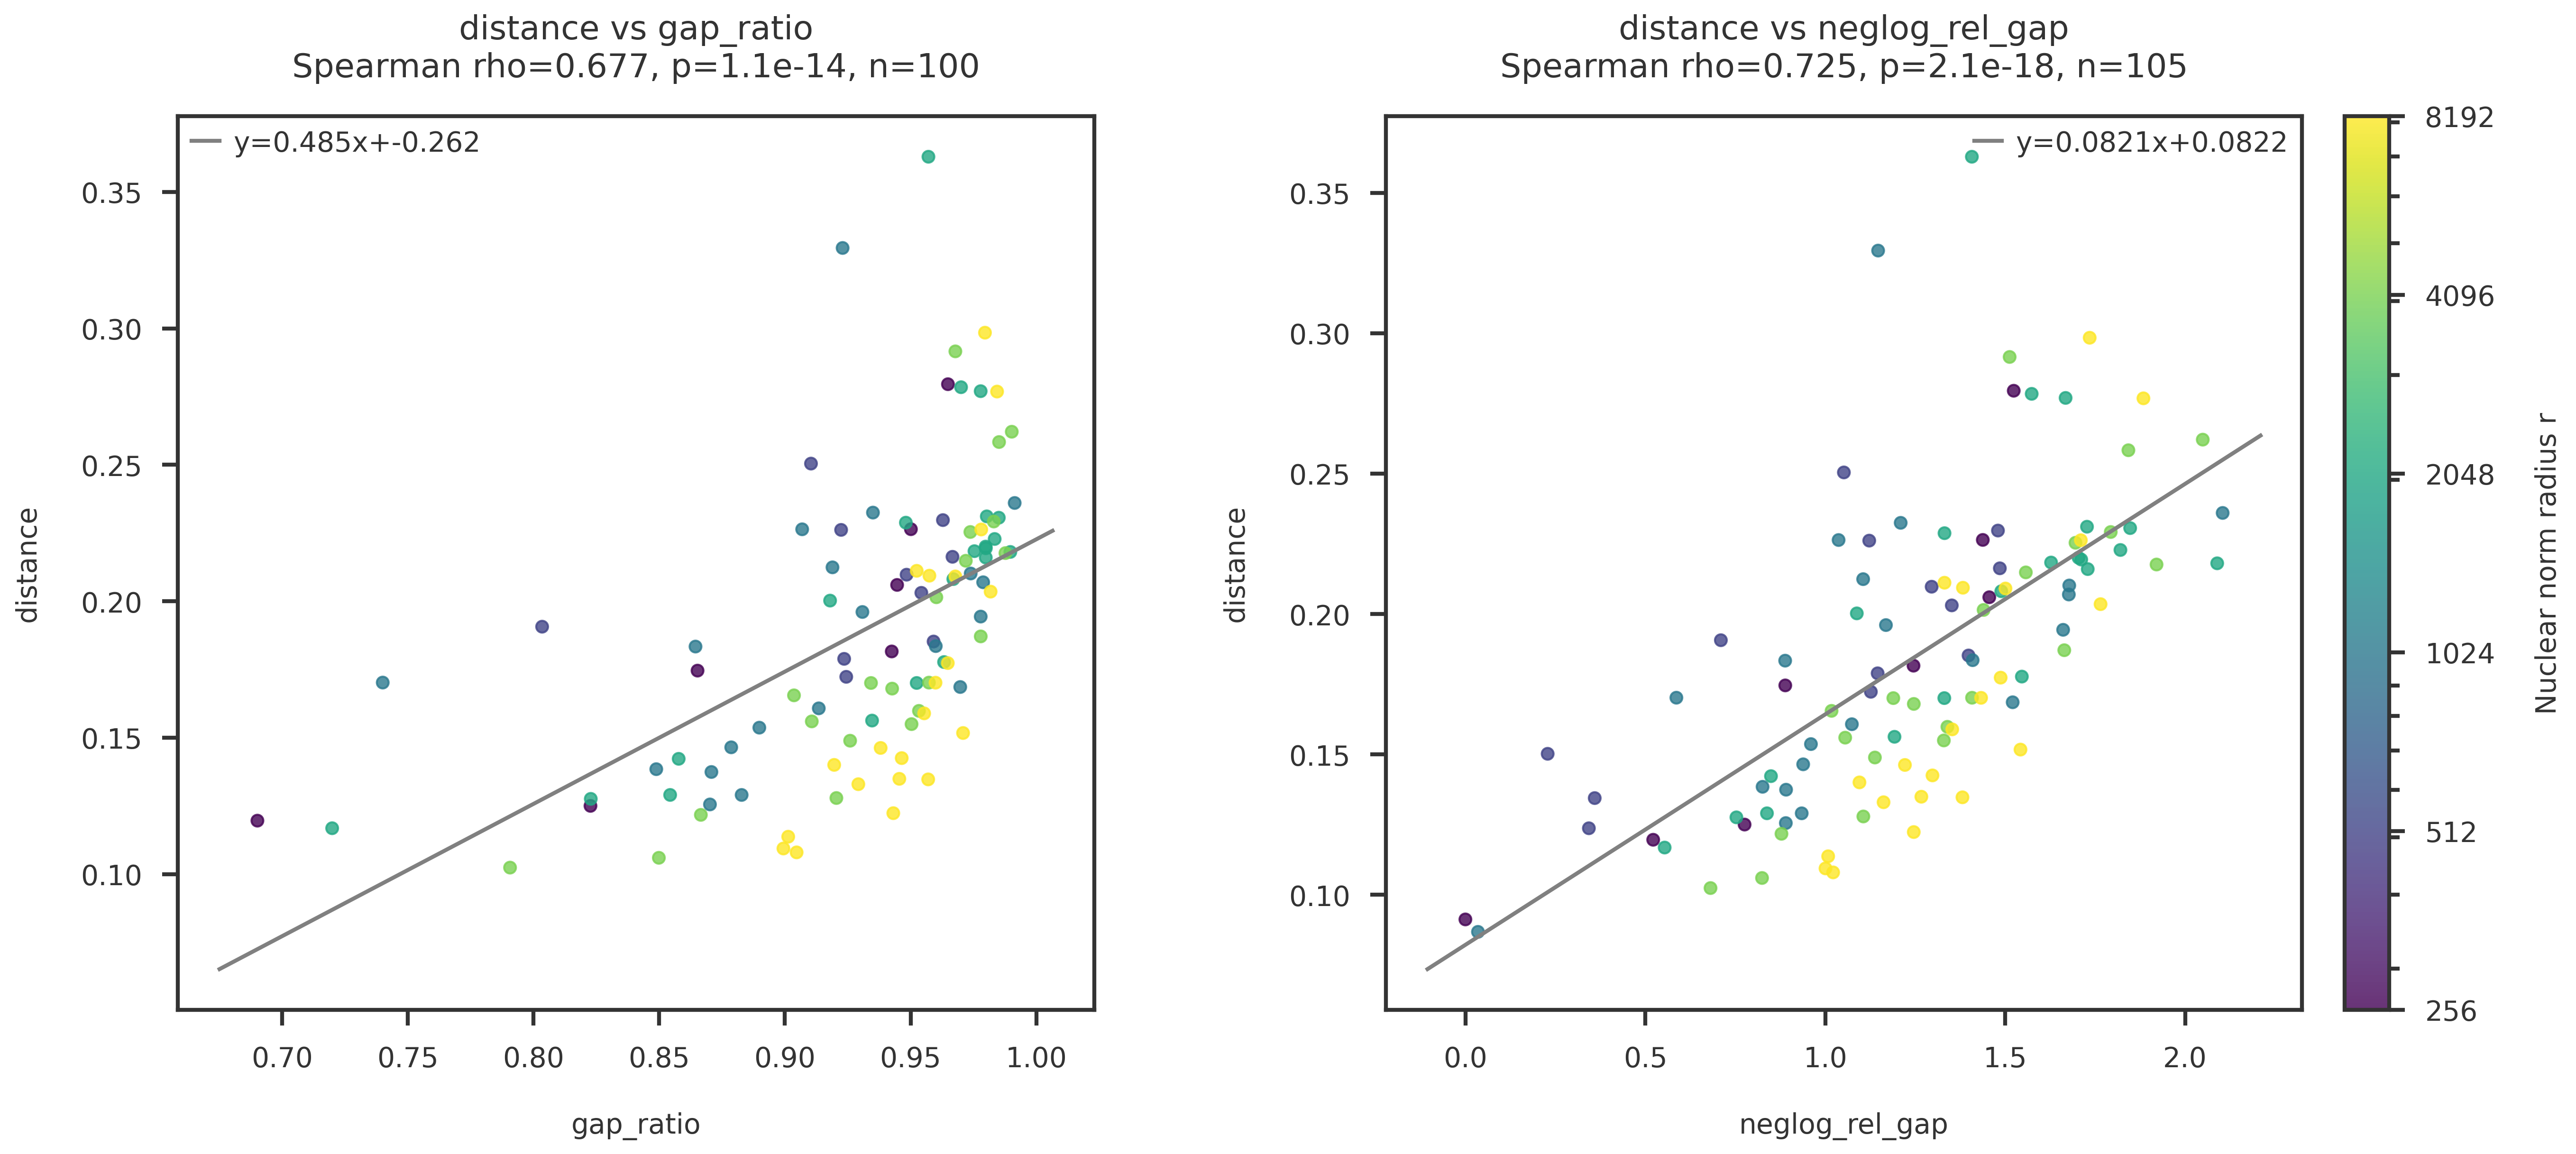

In [17]:
energy_mean_df = (
    energy_df
    .groupby(["nucnorm", "k"], as_index=False)
    .agg(
        distance=("distance", "mean"),
        gap_ratio=("gap_ratio", "mean"),
        rel_s_norm_gap=("rel_s_gap", "mean"),
        neglog_rel_gap=("neglog_rel_gap", "mean"),
        s_norm=("s_norm", "mean"),
    )
)

fig = plt.figure(figsize=(18, 8), constrained_layout=True)
gs = fig.add_gridspec(nrows=1, ncols=2, 
                      width_ratios=[1, 1],  # heatmap, line plot
                      wspace=0.1, hspace=0.05,
                     )
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
nucnorm_values = rank_list[8:14]
k_values = np.arange(5, 26)
color_norm = mpl_colors.LogNorm(vmin=np.min(nucnorm_values), vmax=np.max(nucnorm_values))

_, sc = make_gap_distance_scatter(ax1, energy_mean_df, x="gap_ratio", 
                          nucnorm_values=nucnorm_values, k_values=k_values, color_norm = color_norm)
_, _  = make_gap_distance_scatter(ax2, energy_mean_df, x="neglog_rel_gap", 
                          nucnorm_values=nucnorm_values, k_values=k_values, color_norm = color_norm)

cbar = fig.colorbar(sc, ax=[ax1, ax2], pad=0.02)
cbar.set_label("Nuclear norm radius r")
cbar.set_ticks(nucnorm_values)
cbar.set_ticklabels([str(int(r)) for r in nucnorm_values])

plt.show()

**The spectral gap is the likely cause of the non-monotonicity.** 
The top-k left-singular subspace of is only well-identified when 
$\sigma_k(X) - \sigma_{k+1}(X)$ is large (Davis-Kahan).
When that gap is small, tiny differences between halves rotate $U_k$ a lot, 
and projection_distance blows up.

In the above plots, we show the projection distances below a certain threshold, 
and observe that they are directly correlated with the gap ratio $\sigma_{k+1}(X) / \sigma_{k}(X)$.
A high gap ratio indicates that the successive singular values are not well-separated,
and hence the singular subspaces are not well-identified (large projection distance).